In [2]:
import tensorflow as tf
import cv2
import os
import matplotlib as plt
import numpy as np

In [2]:
img_array=cv2.imread("Face Expression DataSet/Data/Training/0/Training_3908.jpg")

In [3]:
img_array.shape

(48, 48, 3)

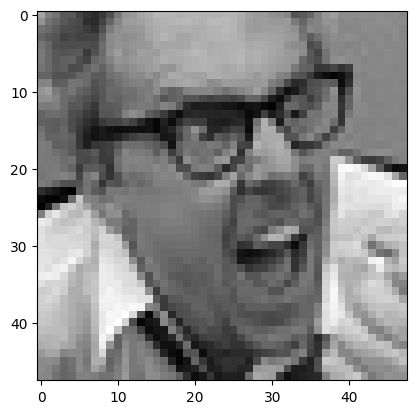

In [4]:
import matplotlib.pyplot as plt
plt.imshow(img_array)

In [5]:
Datadirectory='Face Expression DataSet/Data/Training'

In [6]:
Classes=["0","1","2","3","4","5","6"]

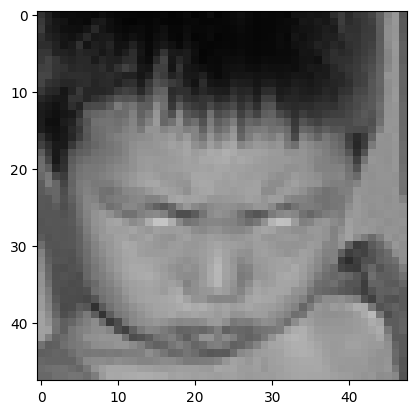

In [7]:
import cv2
for category in Classes:
    path=os.path.join(Datadirectory, category)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.show()
        break
    break

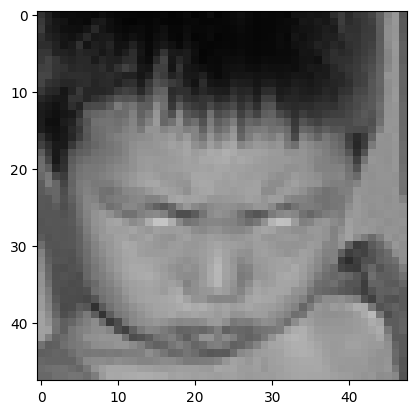

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# Define the path where images are stored
path =os.path.join(Datadirectory, category)

for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path, img))

    # Convert BGR to RGB (Corrected function name)
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(img_array)
    plt.show()
    
    break  # Display only the first image


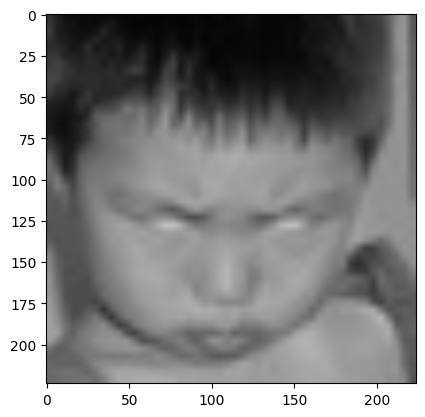

In [9]:
img_size=224
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB))
plt.show()

In [10]:
new_array.shape

(224, 224, 3)

In [11]:
#read all img and convert into array
training_Data=[]
def create_training_Data():
    for category in Classes:
        path=os.path.join(Datadirectory, category)
        class_num=Classes.index(category) #labels
        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img))
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_Data.append([new_array,class_num])
            except Exception as e:
                pass

In [12]:
create_training_Data()

In [13]:
print(len(training_Data))

12800


In [14]:
import random
random.shuffle(training_Data) # because it should not learn the seq.

In [15]:
X=[] # data feature
y=[] # label

for features,label in training_Data:
    X.append(features)
    y.append(label)
X=np.array(X).reshape(-1, img_size, img_size,3) #convert it to 4 deminsion 

In [16]:
X.shape

(12800, 224, 224, 3)

In [17]:
print(img_array)

[[[ 50  50  50]
  [ 32  32  32]
  [ 15  15  15]
  ...
  [133 133 133]
  [151 151 151]
  [ 86  86  86]]

 [[ 57  57  57]
  [ 34  34  34]
  [ 22  22  22]
  ...
  [138 138 138]
  [151 151 151]
  [ 89  89  89]]

 [[ 61  61  61]
  [ 30  30  30]
  [ 24  24  24]
  ...
  [142 142 142]
  [149 149 149]
  [ 89  89  89]]

 ...

 [[103 103 103]
  [100 100 100]
  [100 100 100]
  ...
  [149 149 149]
  [104 104 104]
  [ 85  85  85]]

 [[107 107 107]
  [111 111 111]
  [113 113 113]
  ...
  [151 151 151]
  [120 120 120]
  [ 86  86  86]]

 [[104 104 104]
  [104 104 104]
  [112 112 112]
  ...
  [143 143 143]
  [136 136 136]
  [ 83  83  83]]]


In [18]:
#normalize the data
X=X/255.0;

In [19]:
type(y)

list

In [20]:
Y=np.array(y)
Y.shape

(12800,)

In [21]:
#Model Tranfer Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [22]:
model=tf.keras.applications.EfficientNetB0()

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 19s 1us/step


In [23]:
model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,330,571 (20.33 MB)

 Trainable params: 5,288,548 (20.17 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [24]:
#Transfer learning tuning
base_input=model.layers[1].input


In [25]:
base_input

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [26]:
base_output=model.layers[-2].output

In [27]:
base_output

<KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_239>

In [28]:
final_output=layers.Dense(128)(base_output)
final_ouput=layers.Activation('relu')(final_output)
final_output=layers.Dense(64)(final_ouput)
final_ouput=layers.Activation('relu')(final_output)
final_output=layers.Dense(7,activation='softmax')(final_ouput)

In [29]:
final_output

<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_245>

In [30]:
new_model=keras.Model(inputs=base_input, outputs=final_output)


In [38]:
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 12,582,706 (48.00 MB)

 Trainable params: 4,180,227 (15.95 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 8,360,456 (31.89 MB)

In [39]:
new_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [40]:
history=new_model.fit(X, Y, epochs=30, batch_size=64, verbose=1)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1097s 5s/step - accuracy: 0.5107 - loss: 1.3020
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1053s 5s/step - accuracy: 0.6170 - loss: 1.0231
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1047s 5s/step - accuracy: 0.6810 - loss: 0.8615
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1057s 5s/step - accuracy: 0.7381 - loss: 0.7284
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1051s 5s/step - accuracy: 0.7766 - loss: 0.6063
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1052s 5s/step - accuracy: 0.8238 - loss: 0.4925
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1077s 5s/step - accuracy: 0.8607 - loss: 0.3993
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1071s 5s/step - accuracy: 0.8856 - loss: 0.3188
Epoch 9/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1067s 5s/step - accuracy: 0.9017 - loss: 0.2750
Epoch 10/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1071s 5s/step - accuracy: 0.9136 - loss: 0.2379
Epoch 11/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1069s 5s/step - accuracy: 0.9372 - loss: 0.1830
Epoch 12/30
200/200 ━━━━━━━━━━

In [41]:
new_model.save("FER13ModelEfficient.h5")  # Saves as an HDF5 file


In [42]:
new_model.save("FER13ModelEfficient.keras")  # Saves as an HDF5 file


In [43]:
import tensorflow as tf
import numpy as np
import os
import cv2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model("FER13ModelEfficient.h5")

# Define the dataset directory
Test_Directory = 'Face Expression DataSet/Data/testing'
Classes = ["0", "1", "2", "3", "4", "5", "6"]

# Image size
img_size = 224

# Function to preprocess test images
def load_test_data():
    test_data = []
    y_true = []
    
    for category in Classes:
        path = os.path.join(Test_Directory, category)
        class_num = Classes.index(category)  # Label
        
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img))
                new_array = cv2.resize(img_array, (img_size, img_size)) / 255.0  # Normalize
                test_data.append(new_array)
                y_true.append(class_num)
            except Exception as e:
                pass
    
    return np.array(test_data), np.array(y_true)

# Load test data
X_test, y_test = load_test_data()

# Check the shape
print("Test Data Shape:", X_test.shape)
print("Labels Shape:", y_test.shape)


Test Data Shape: (1003, 224, 224, 3)
Labels Shape: (1003,)


In [44]:
# Get predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Get class with highest probability


32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 466ms/step


Accuracy: 0.1226
Precision: 0.0778
Recall: 0.1226
F1 Score: 0.0624


C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


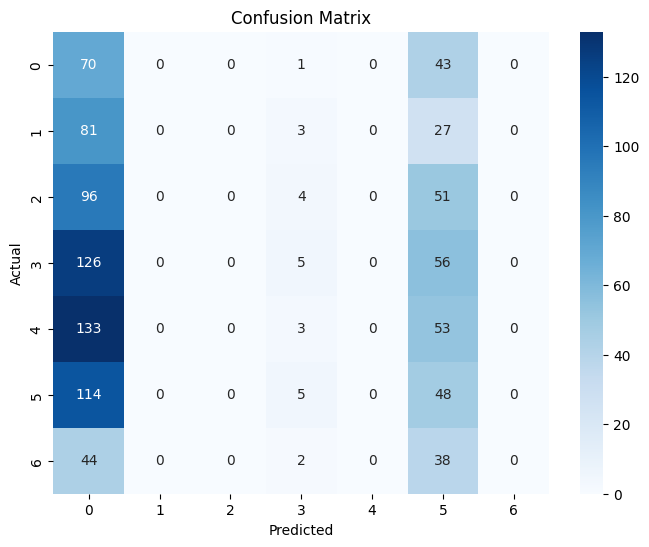

In [45]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1-score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=Classes, yticklabels=Classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [46]:
# Load test dataset
Datadirectory = 'Face Expression DataSet/Data/Testing'
Classes = ["0", "1", "2", "3", "4", "5", "6"]

test_data = []
img_size = 224  # Ensure same size as training images

# Preprocess test images
for category in Classes:
    path = os.path.join(Datadirectory, category)
    class_num = Classes.index(category)  # Labels
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            new_array = cv2.resize(img_array, (img_size, img_size))
            test_data.append([new_array, class_num])
        except Exception as e:
            pass

# Shuffle data
import random
random.shuffle(test_data)

# Separate features and labels
X_test = []
Y_test = []
for features, label in test_data:
    X_test.append(features)
    Y_test.append(label)

# Convert to NumPy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 3) / 255.0
Y_test = np.array(Y_test)


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Load trained model
from tensorflow import keras
model = keras.models.load_model("FER13ModelEfficient.h5")

# Evaluate on test data
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 403ms/step - accuracy: 0.1357 - loss: 3.4457
Test Accuracy: 0.1226, Test Loss: 3.4711


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 443ms/step
              precision    recall  f1-score   support

           0       0.11      0.61      0.18       114
           1       0.00      0.00      0.00       111
           2       0.00      0.00      0.00       151
           3       0.22      0.03      0.05       187
           4       0.00      0.00      0.00       189
           5       0.15      0.29      0.20       167
           6       0.00      0.00      0.00        84

    accuracy                           0.12      1003
   macro avg       0.07      0.13      0.06      1003
weighted avg       0.08      0.12      0.06      1003



C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


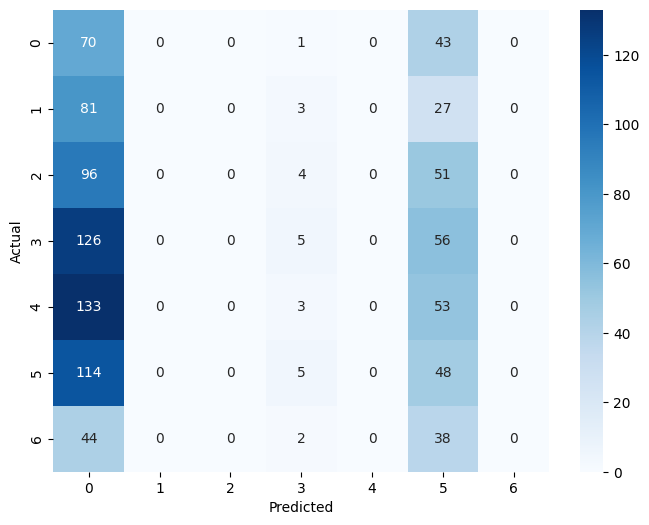

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Print classification report
print(classification_report(Y_test, y_pred))

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Classes, yticklabels=Classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [51]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("FER13ModelEfficient.h5")

# Ensure training data is loaded
# X, Y = (Reload training data if lost)

# Evaluate the model
loss, accuracy = model.evaluate(X, Y)

print(f"Final Training Accuracy: {accuracy*100:.2f}%")
print(f"Final Training Loss: {loss:.4f}")


400/400 ━━━━━━━━━━━━━━━━━━━━ 177s 428ms/step - accuracy: 0.1376 - loss: 3.4359
Final Training Accuracy: 13.90%
Final Training Loss: 3.4676


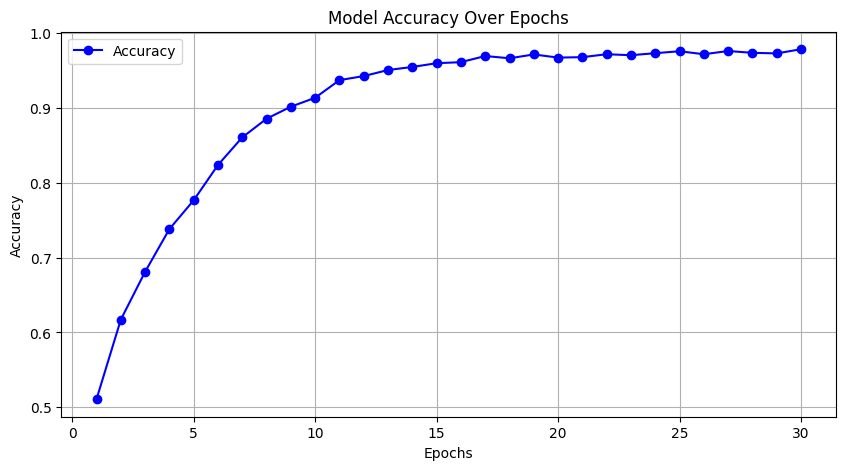

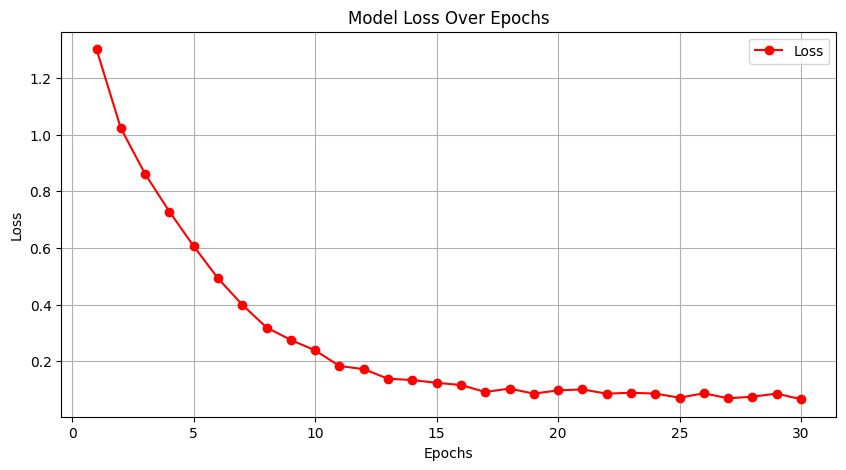

In [50]:
import matplotlib.pyplot as plt

# Assuming `history` contains accuracy and loss values for each epoch
epochs = list(range(1, 31))  # 30 epochs

# Manually extracted accuracy and loss values (from your output)
accuracy = [0.5107, 0.6170, 0.6810, 0.7381, 0.7766, 0.8238, 0.8607, 0.8856, 0.9017, 0.9136, 
            0.9372, 0.9426, 0.9507, 0.9548, 0.9598, 0.9612, 0.9694, 0.9664, 0.9715, 0.9673, 
            0.9679, 0.9718, 0.9705, 0.9732, 0.9758, 0.9718, 0.9761, 0.9737, 0.9729, 0.9785]

loss = [1.3020, 1.0231, 0.8615, 0.7284, 0.6063, 0.4925, 0.3993, 0.3188, 0.2750, 0.2379, 
        0.1830, 0.1716, 0.1380, 0.1332, 0.1234, 0.1158, 0.0910, 0.1031, 0.0852, 0.0968, 
        0.1003, 0.0851, 0.0885, 0.0853, 0.0709, 0.0866, 0.0687, 0.0744, 0.0853, 0.0655]

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracy, marker='o', linestyle='-', color='b', label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.legend()
plt.grid()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, marker='o', linestyle='-', color='r', label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()



In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import filedialog

# Load the trained model
model = tf.keras.models.load_model("FER13ModelEfficient.h5")

# Define class labels (assuming these are the correct labels)
class_labels = ["0", "1", "2", "3", "4", "5", "6"]

# Function to process and predict an image
def predict_expression():
    # Open file dialog to select an image
    file_path = filedialog.askopenfilename(filetypes=[("Face Expression DataSet/Data/testing/1/PrivateTest_807646.jpg", "*.jpg;*.jpeg;*.png")])
    
    if not file_path:
        print("No file selected.")
        return

    # Read and preprocess the image
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img_resized = cv2.resize(img, (224, 224))   # Resize to match model input size
    img_normalized = img_resized / 255.0        # Normalize pixel values
    
    # Reshape to match model input shape (1, 224, 224, 3)
    img_input = np.expand_dims(img_normalized, axis=0)

    # Make a prediction
    predictions = model.predict(img_input)
    predicted_class = np.argmax(predictions)  # Get the class index with highest probability
    predicted_label = class_labels[predicted_class]  # Get the class label

    # Display the image with predicted label
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}")
    plt.show()

# Run the function
predict_expression()


In [3]:
new_model=tf.keras.models.load_model('FER13ModelEfficient.h5')

In [4]:
frame=cv2.imread("Face Expression DataSet/Data/images.jpg")

In [5]:
frame.shape

(183, 275, 3)

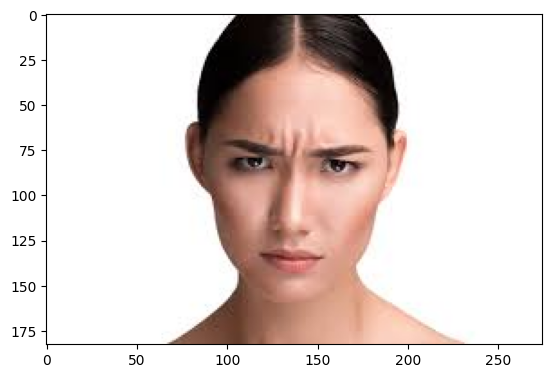

In [6]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))

In [7]:
#FACE DETECTION ALGO
faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [8]:
gray=cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [9]:
gray.shape

(183, 275)

In [10]:
faces=faceCascade.detectMultiScale(gray,1.1,4)
for x,y,w,h in faces:
    roi_gray=gray[y:y+h, x:x+w]
    roi_color=frame[y:y+h, x:x+w]
    cv2.rectangle(frame,(x,y), (x+w, y+h), (255,0,0),2)
    facess=faceCascade.detectMultiScale(roi_gray)
    if len(faces)== 0:
        print("Face not detected")
    else:
        for (ex,ey,ew,eh) in facess:
            face_roi=roi_color[ey: ey+eh, ex:ex +ew]

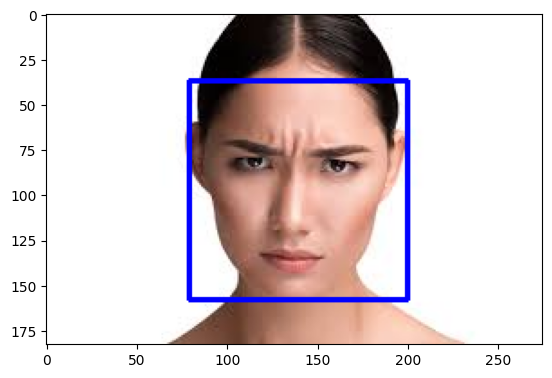

In [11]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

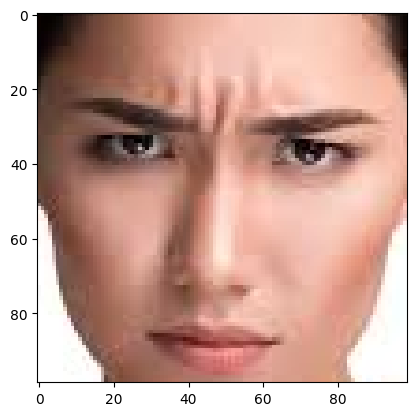

In [12]:
plt.imshow(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))

In [13]:
final_image=cv2.resize(face_roi,(224,224))
final_image=np.expand_dims(final_image,axis=0)
final_image=final_image/225.0

In [14]:
Predictions=new_model.predict(final_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [15]:
Predictions[0]

array([3.5007086e-01, 5.6215143e-04, 2.8353073e-02, 1.8478746e-02,
       1.1097900e-02, 5.9128350e-01, 1.5380814e-04], dtype=float32)

In [16]:
np.argmax(Predictions)

np.int64(5)

In [51]:
#REAL DEMO
import cv2
path='haarcascade_frontalface_default.xml'
font_scale=1.5
font=cv2.FONT_HERSHEY_PLAIN

rectangle_bgr=(225,225,225)
img=np.zeros((500,500))
text="Some text in a box!"
(text_width,text_height)=cv2.getTextSize(text,font,fontScale=font_scale,thickness=1)[0]
text_offset_x=10
text_offset_y=img.shape[0]-25

box_coords=((text_offset_x, text_offset_y), (text_offset_x + text_width + 2, text_offset_y-text_height-2))
cv2.rectangle(img, box_coords[0], box_coords[1], rectangle_bgr, cv2.FILLED)
cv2.putText(img,text,(text_offset_x, text_offset_y), font, fontScale=font_scale, color=(0,0,0), thickness=1)

cap=cv2.VideoCapture(1)
if not cap.isOpened():
    cap= cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Webcam")

while True:
    ret, frame=cap.read()
    faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces=faceCascade.detectMultiScale(gray,1.1,4)
    for x,y,w,h in faces:
        roi_gray=gray[y:y+h, x:x+w]
        roi_color=frame[y:y+h, x:x+w]
        cv2.rectangle(frame,(x,y), (x+w, y+h), (255,0,0),2)
        facess=faceCascade.detectMultiScale(roi_gray)
        if len(faces)== 0:
            print("Face not detected")
        else:
            for (ex,ey,ew,eh) in facess:
                face_roi=roi_color[ey: ey+eh, ex:ex +ew]
    final_image=cv2.resize(face_roi,(224,224))
    final_image=np.expand_dims(final_image,axis=0)
    final_image=final_image/225.0

    font=cv2.FONT_HERSHEY_SIMPLEX
    Predictions=new_model.predict(final_image)

    font_scale=1.5
    font=cv2.FONT_HERSHEY_PLAIN

    if(np.argmax(Predictions)==0):
        status="Angry"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(0,0,255))

        
    elif (np.argmax(Predictions)==1):
        status="Disgust"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(0,0,255))

    elif (np.argmax(Predictions)==3):
        status="Happy"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))

    elif (np.argmax(Predictions)==4):
        status="Sad"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))


    elif (np.argmax(Predictions)==5):
        status="Suprise"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))

    else:
        status="Neural"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))


    cv2.imshow("Face Emotion Recogition",frame)
    
    if cv2.waitKey(2) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyALLWindows()
        
        
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

In [54]:
#RUNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
import cv2
import numpy as np
from collections import Counter
from tensorflow.keras.models import load_model

# Load the trained model
new_model = load_model("FER13Model.keras")  # Replace with your actual model path

# Load face detection model
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Webcam")

# Store last few predictions for stability
prediction_history = []
history_size = 5  # Number of recent predictions to consider

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        roi_color = frame[y:y+h, x:x+w]
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Resize face ROI to match model input
        final_image = cv2.resize(roi_color, (224, 224))
        final_image = np.expand_dims(final_image, axis=0) / 255.0  # Normalize

        # Make prediction
        Predictions = new_model.predict(final_image)
        prediction_history.append(np.argmax(Predictions))

        # Keep only the last `history_size` predictions
        if len(prediction_history) > history_size:
            prediction_history.pop(0)

        # Choose the most common prediction
        most_common_prediction = Counter(prediction_history).most_common(1)[0][0]
        emotion_dict = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}
        status = emotion_dict.get(most_common_prediction, "Unknown")

        # Display emotion label
        cv2.rectangle(frame, (0, 0), (175, 50), (0, 0, 0), -1)
        cv2.putText(frame, status, (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show video
    cv2.imshow("Face Emotion Recognition", frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━

KeyboardInterrupt: 